Correlation between Green Index and PM2.5: -0.98


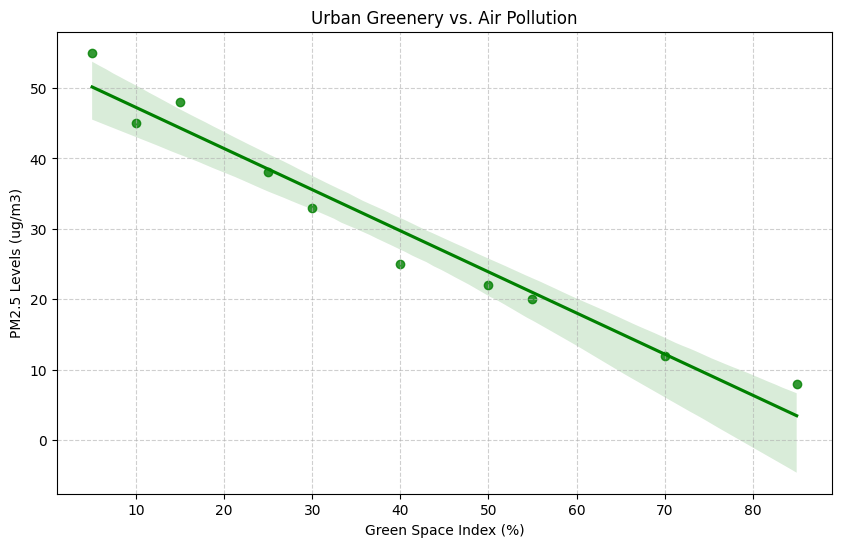

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Create the dataset
data = {
    'Neighborhood': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Green_Index': [10, 25, 15, 40, 55, 30, 70, 85, 5, 50],
    'Industry_Dist': [1.2, 1.5, 0.8, 3.5, 4.0, 2.1, 5.2, 6.0, 0.5, 2.5],
    'PM25': [45, 38, 48, 25, 20, 33, 12, 8, 55, 22]
}

df = pd.DataFrame(data)

# 2. Calculate Correlation
corr, _ = pearsonr(df['Green_Index'], df['PM25'])
print(f"Correlation between Green Index and PM2.5: {corr:.2f}")

# 3. Visual Analysis
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Green_Index', y='PM25', color='green', marker='o')

plt.title('Urban Greenery vs. Air Pollution')
plt.xlabel('Green Space Index (%)')
plt.ylabel('PM2.5 Levels (ug/m3)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Correlation between Industry Distance and PM2.5: -0.96


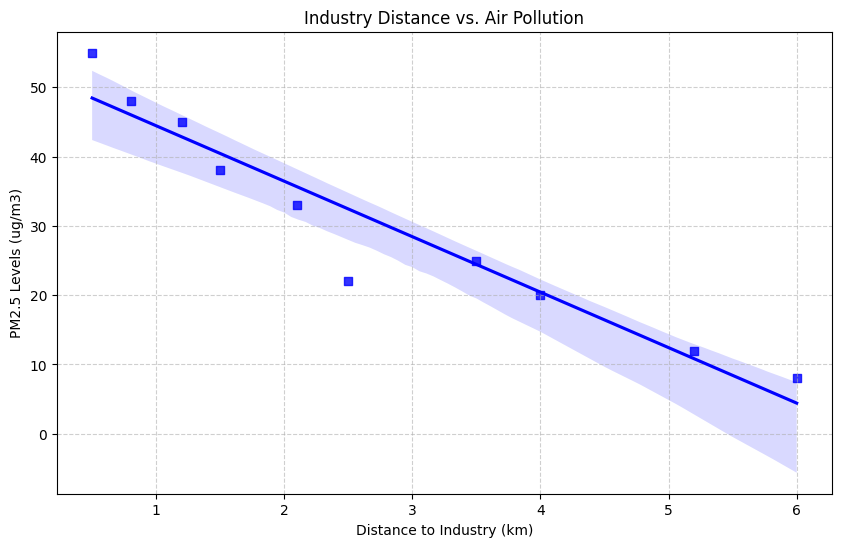

In [2]:
# 2. Calculate Correlation
corr, _ = pearsonr(df['Industry_Dist'], df['PM25'])
print(f"Correlation between Industry Distance and PM2.5: {corr:.2f}")

# 3. Visual Analysis
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Industry_Dist', y='PM25', color='blue', marker='s')

plt.title('Industry Distance vs. Air Pollution')
plt.xlabel('Distance to Industry (km)')
plt.ylabel('PM2.5 Levels (ug/m3)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import statsmodels.api as sm

# 1. Prepare the variables
X = df[['Green_Index', 'Industry_Dist']]
X = sm.add_constant(X) 
y = df['PM25']

# 2. Fit the model
model = sm.OLS(y, X).fit()

# 3. Print the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   PM25   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     80.86
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.45e-05
Time:                        23:00:21   Log-Likelihood:                -25.337
No. Observations:                  10   AIC:                             56.67
Df Residuals:                       7   BIC:                             57.58
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            53.1509      2.118     25.093

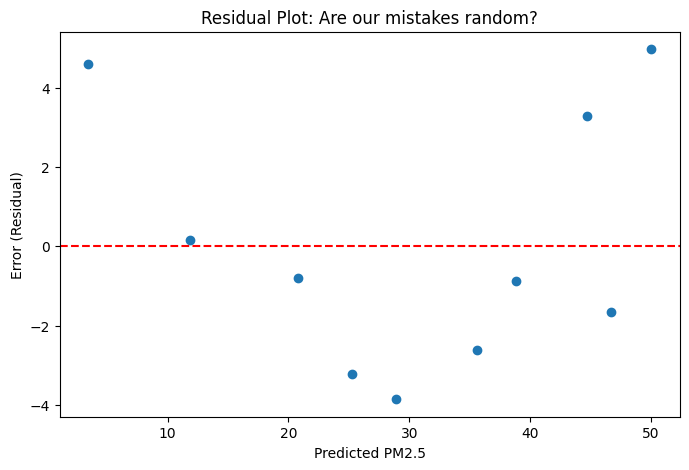

In [4]:
# Calculate the residuals
df['Predictions'] = model.predict(X)
df['Residuals'] = df['PM25'] - df['Predictions']

# Plot the residuals
plt.figure(figsize=(8, 5))
plt.scatter(df['Predictions'], df['Residuals'])
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted PM2.5')
plt.ylabel('Error (Residual)')
plt.show()

In [5]:
# Create the interaction term
df['Green_x_Dist'] = df['Green_Index'] * df['Industry_Dist']

corr, _ = pearsonr(df['Green_x_Dist'], df['PM25'])
print(f"Correlation between Green Index * Industry Distance and PM2.5: {corr:.2f}")

# Prepare the new feature matrix
X_interaction = df[['Green_Index', 'Industry_Dist', 'Green_x_Dist']]
X_interaction = sm.add_constant(X_interaction)

# Fit the new model
model_interaction = sm.OLS(y, X_interaction).fit()

print(model_interaction.summary())

Correlation between Green Index * Industry Distance and PM2.5: -0.89
                            OLS Regression Results                            
Dep. Variable:                   PM25   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     308.2
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           5.85e-07
Time:                        23:00:21   Log-Likelihood:                -16.028
No. Observations:                  10   AIC:                             40.06
Df Residuals:                       6   BIC:                             41.27
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [ ]:
import joblib

joblib.dump(model_interaction, 'C:\\projects\\GreenSpace-Pollution-AI\\src\\trained_model.pkl')
print("Model saved successfully!")

Model saved successfully!
